1.What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.


Point Anomalies (Global Outliers):


Definition: A single data instance is anomalous if it is far removed from the rest of the dataset.
Example: A credit card purchase of $5,000 when your average purchase is $50.
Example: A sudden, isolated spike in system CPU usage.

Contextual Anomalies (Conditional Anomalies):


Definition: Data points that appear normal in isolation but are considered anomalous when within a specific context (such as time, location, or condition).
Example:
 is normal in summer but abnormal in winter.
Example: High energy usage at 2:00 AM, which would be normal at 6:00 PM.


Collective Anomalies:


Definition: A set of data instances that, while possibly appearing normal individually, are anomalous when considered together as a group or sequence.
Example: A user typing a password incorrectly five times in ten seconds (individual characters are fine, but the sequence indicates a brute-force attack).
Example: Multiple, simultaneous, and coordinated server connections to a new IP address, indicating a potential network breach

Key Applications


Anomaly detection is widely used in:
Fraud Detection: Identifying unusual banking or insurance transactions.
Cybersecurity: Detecting intrusions, malware, or data exfiltration.
System Health Monitoring: Finding failing hardware in industrial systems or network devices

2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of
their approach and suitable use cases.


Isolation Forest:


Approach: Builds a forest of decision trees. It picks a feature and a random split value. Because anomalies are rare and different, they are separated from the rest of the data early, resulting in shorter path lengths.
Use Cases: Efficient for high-speed, large-scale data, such as credit card fraud detection, cybersecurity, and IT network traffic monitoring.


DBSCAN (Density-Based Spatial Clustering of Applications with Noise):


Approach: Groups points that are close together (based on minPts and epsilon) into clusters. Points in low-density regions that are not close to any cluster are labeled as outliers.
Use Cases: Best for spatial datasets (e.g., GPS data) or when anomalies exist in low-density regions relative to dense "normal" clusters.



Local Outlier Factor (LOF):



Approach: Calculates the local density of a point compared to its neighbors. If a point has a much lower density than its neighbors, it is classified as a local anomaly.
Use Cases: Suitable when the dataset has clusters of varying densities. It is excellent at detecting anomalies that are not globally abnormal but are unusual for their immediate local area.

 3: What are the key components of a Time Series? Explain each with one
example.


1. Trend (T): The long-term, consistent upward or downward movement in the data over a long period, ignoring short-term fluctuations.
Example: A steady increase in annual worldwide smartphone sales over the past decade.

2. Seasonal Variation (S): Predictable, repeating patterns that occur within a fixed period, such as daily, weekly, or yearly, often due to weather or holidays.
Example: A surge in ice cream sales during the summer months every year.

3. Cyclical Variation (C): Rhythmic, long-term oscillations that occur over a period of more than one year (usually 3–10 years), not fixed like seasons (e.g., economic cycles).
Example: A 5-year boom and bust cycle in the housing market.

4. Irregular Variation (I): Unpredictable, random fluctuations that are not part of a pattern and are caused by unforeseen events.
Example: A sudden drop in air travel following a natural disaster or pandemic

 4: Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one?

Definition of Stationarity


A process is considered stationary if its behavior does not change over time, meaning:
Constant Mean: The trend is absent.
Constant Variance: The amplitude of fluctuations remains consistent.
Constant Autocorrelation: The covariance between two time periods depends only on the distance between them, not the specific time.


Testing for Stationarity


Visual Inspection (Time Plot): Plot the time series to identify visible trends (mean changes) or changing volatility (variance changes).
Augmented Dickey-Fuller (ADF) Test: A statistical test where the Null Hypothesis (
) is that the series is non-stationary. A low
-value (
) indicates rejecting
 and accepting that the series is stationary.
KPSS Test: Complementary to ADF;
 is that the series is stationarity.
Autocorrelation Plot (ACF): A non-stationary series shows slow, linear decline in autocorrelation, while a stationary series drops to zero quickly.


Transforming Non-Stationary to Stationary


If a series is non-stationary, use the following techniques:
Differencing: Calculate the difference between consecutive observations (
). This removes trends and stabilizes the mean.
Log Transformation: Apply a natural logarithm (np.log()) to reduce non-constant variance (heteroscedasticity), transforming exponential trends to linear ones.
Seasonal Differencing: Subtracting a value from its counterpart in the previous season () to remove seasonal trends.
Detrending: Fitting a regression model (e.g., linear) to the trend and subtracting it from the series.

 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.


1. AR (Autoregressive) Model -



Structure: Predicts future values based on a linear combination of past values (
 lags).
Application: Suitable for stationary data where current values depend directly on previous values, such as temperature, according to this Milvus article

2. MA (Moving Average) Model -



Structure: Models the current value as a linear combination of past forecast errors (
 lags).
Application: Used to smooth out random shocks or unexpected noise in data, notes HackMD.


3. ARIMA (Autoregressive Integrated Moving Average) -








Structure: Combines AR and MA with "I" (Integration/Differencing) to handle non-stationary data. It makes data stationary by computing differences (
).
Application: Best for non-seasonal data with trends, such as stock prices or yearly sales without seasonal dips


4. SARIMA (Seasonal ARIMA) -















Structure: Extends ARIMA by adding seasonal AR, seasonal MA, and seasonal differencing terms to handle cycles of length '
'.
Application: Used for data with clear, recurring, seasonal patterns (e.g., monthly sales spikes every December),


5. SARIMAX (Seasonal ARIMA with Exogenous Variables) -
















Structure: Adds an external, exogenous variable (
) component to the SARIMA model.
Application: Ideal for forecasting seasonal data influenced by external factors, such as forecasting ice cream sales (seasonal) based on temperature and marketing spend (exogenous).

6.Load a time series dataset (e.g., AirPassengers), plot the original series,
and decompose it into trend, seasonality, and residual components

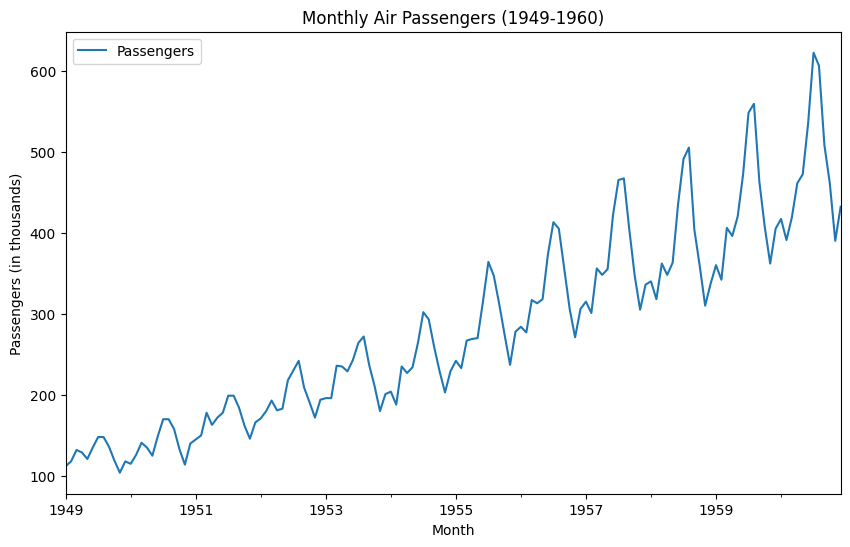

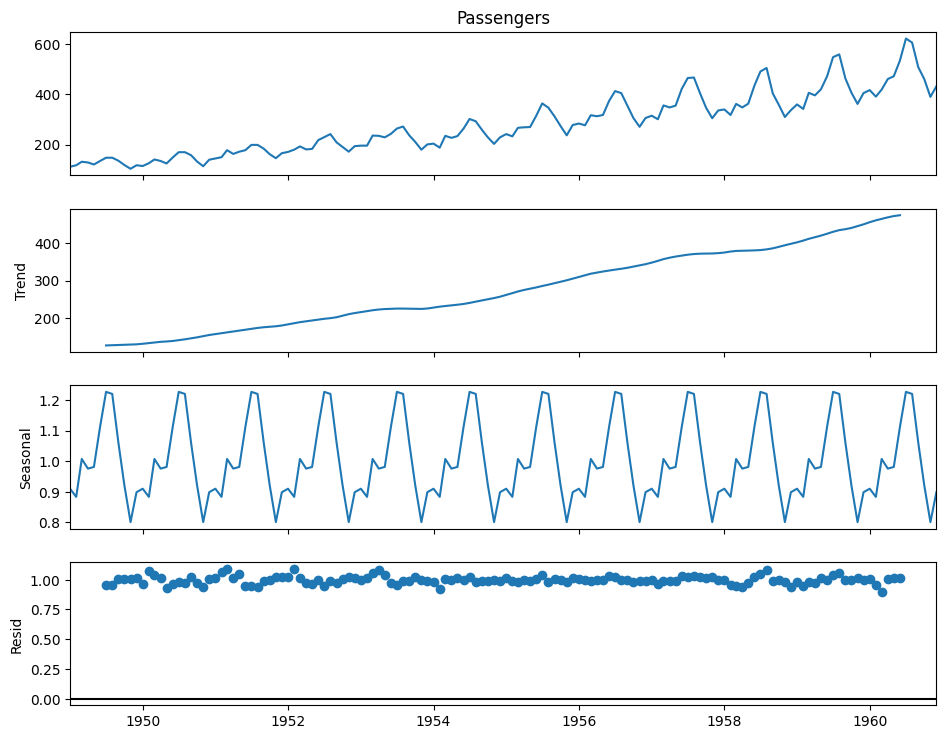

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Load the dataset (using a common URL)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
data.columns = ['Passengers']

# 2. Plot the original series
data.plot(figsize=(10, 6), title='Monthly Air Passengers (1949-1960)')
plt.ylabel('Passengers (in thousands)')
plt.show()

# 3. Decompose into trend, seasonality, and residuals
# Model="multiplicative" is appropriate because variance increases with time
result = seasonal_decompose(data['Passengers'], model='multiplicative', period=12)

# 4. Plot the components
fig = result.plot()
fig.set_size_inches(10, 8)
plt.show()



 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
detect anomalies. Visualize the anomalies on a 2D scatter plot.

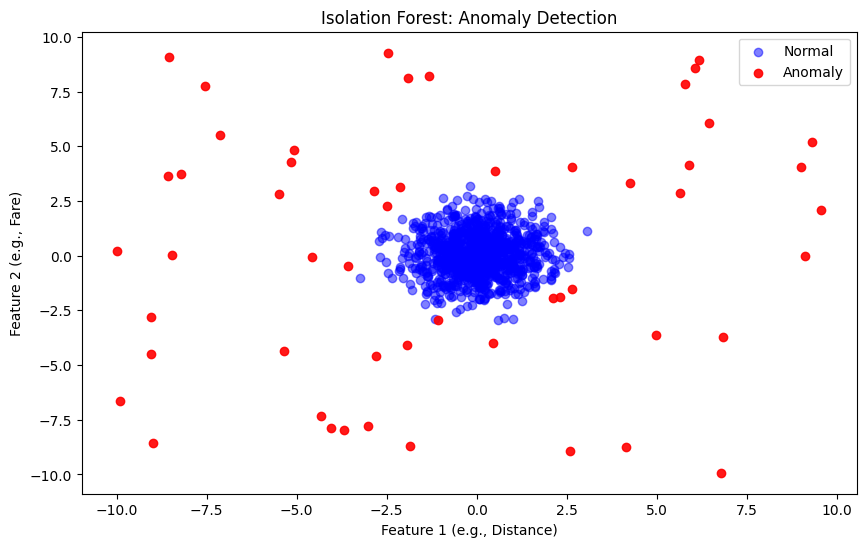

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Generate/Load Sample Numerical Data (NYC Taxi Fare Example)
# Features: [Distance, Fare]
np.random.seed(42)
data = np.random.normal(size=(1000, 2))
# Add some outliers
outliers = np.random.uniform(low=-10, high=10, size=(50, 2))
X = np.vstack([data, outliers])

# 2. Train Isolation Forest
# contamination: Proportion of outliers in the data
clf = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
preds = clf.fit_predict(X)

# 3. Visualize the anomalies
# -1 indicates anomalies, 1 indicates normal data
normal = X[preds == 1]
anomaly = X[preds == -1]

plt.figure(figsize=(10, 6))
plt.scatter(normal[:, 0], normal[:, 1], c='blue', label='Normal', alpha=0.5)
plt.scatter(anomaly[:, 0], anomaly[:, 1], c='red', label='Anomaly', alpha=0.9)
plt.title('Isolation Forest: Anomaly Detection')
plt.xlabel('Feature 1 (e.g., Distance)')
plt.ylabel('Feature 2 (e.g., Fare)')
plt.legend()
plt.show()


 8: Train a SARIMA model on the monthly airline passengers dataset.
Forecast the next 12 months and visualize the results.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Load Data
# Assuming 'data' is a DataFrame with 'Month' as index and 'Passengers' column
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, header=0, parse_dates=[0], index_col=0)
data.columns = ['Passengers'] # Ensure column name consistency
data.index.freq = 'MS' # Monthly Start

# 2. Define and Fit Model
# SARIMA(0,1,1)(0,1,1)12 is commonly best for this dataset [6]
model = SARIMAX(data['Passengers'],
                order=(0, 1, 1),
                seasonal_order=(0, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()

# 3. Forecast Next 12 Months
forecast = results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# 4. Visualize Results
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Passengers'], label='Observed')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Airline Passenger Forecast')
plt.legend()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'index'

9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
anomalies and visualize them using matplotlib.

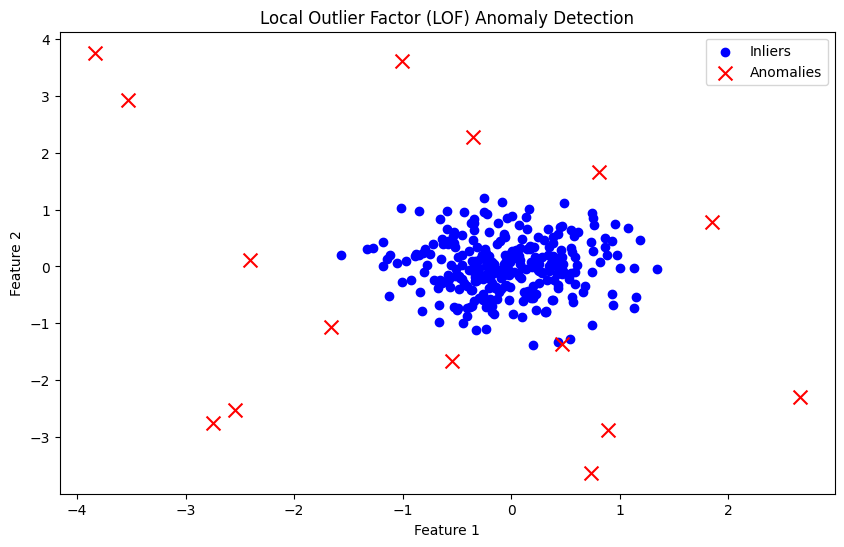

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

# --- 1. Create a sample numerical dataset ---
n_samples = 300
outliers_fraction = 0.05
n_outliers = int(outliers_fraction * n_samples)
n_inliers = n_samples - n_outliers

# Generate inlier data
blobs_params = dict(random_state=0, n_samples=n_inliers, n_features=2)
X, y = make_blobs(centers=[[0, 0], [0, 0]], cluster_std=0.5, **blobs_params)

# Generate outliers
rng = np.random.RandomState(42)
outliers_X = rng.uniform(low=-4, high=4, size=(n_outliers, 2))
X = np.concatenate([X, outliers_X], axis=0)

# --- 2. Apply the Local Outlier Factor (LOF) algorithm ---

# Define the LOF model
# The 'contamination' parameter is the proportion of outliers in the dataset
lof = LocalOutlierFactor(n_neighbors=20, contamination=outliers_fraction)

# Fit the model and predict anomalies
# The fit_predict method returns -1 for outliers and 1 for inliers
y_pred = lof.fit_predict(X)

# Extract anomalies (outliers) and normal points (inliers)
anomalies_indices = np.where(y_pred == -1)
inliers_indices = np.where(y_pred == 1)

anomalies = X[anomalies_indices]
inliers = X[inliers_indices]

# --- 3. Visualize the anomalies using matplotlib ---

plt.figure(figsize=(10, 6))
plt.scatter(inliers[:, 0], inliers[:, 1], c='blue', label='Inliers')
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', marker='x', s=100, label='Anomalies')
plt.title('Local Outlier Factor (LOF) Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


10: You are working as a data scientist for a power grid monitoring company.
Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.
Explain your real-time data science workflow:


● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?


● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?


● How would you validate and monitor the performance over time?


● How would this solution help business decisions or operations?





1. Anomaly Detection in Streaming Data
For streaming 15-minute data (high volume, low latency, seasonal trends), Isolation Forest is the preferred technique.
ResearchGate
ResearchGate
Why Isolation Forest: Unlike LOF or DBSCAN, Isolation Forest excels at handling high-dimensional data (weather, region, time) and is highly efficient in real-time, as it isolates anomalies rather than profiling normal behavior, making it faster and less resource-intensive.
Workflow:
Pre-processing: Normalize energy usage and weather features; apply one-hot encoding for regions.
Streaming Application: Use a sliding window (e.g., last 4 hours or rolling 24-hour baseline) to train or update the Isolation Forest model periodically to adapt to changing seasonal patterns.
Detection: Flag points with low anomaly scores (high isolation) as potential spikes (high usage) or drops (potential equipment failure/metering issue).
Action: Send alert to operations team via a pub/sub system (e.g., Kafka).



2. Time Series Model for Short-Term Forecasting
For 15-minute forecasting, SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors) is the best choice.
Why SARIMAX: The data has strong daily (96 periods per day) and weekly seasonality. SARIMAX (Seasonal ARIMA) handles this, while the 'X' (exogenous) allows incorporating crucial weather data (temperature, humidity) and regional features, which significantly improve accuracy over SARIMA alone.
Implementation:
Stationarity: Apply seasonal differencing to handle non-stationarity in energy usage.
Exogenous Variables: Input weather forecasts (temperature) as exogenous features to account for demand spikes during extreme weather.
Frequency: Set

 for 15-minute data over a 24-hour cycle.



 3. Validation and Monitoring Performance
Real-time models require active, automated monitoring to prevent performance drift.
Validation: Use Walk-Forward Validation (Rolling Forecast). The model predicts the next 15-minute point, receives the actual value, and refits/updates the model for the next 15-minute step.
Metrics: Track MAE (Mean Absolute Error) for accurate magnitude forecasting and MAPE (Mean Absolute Percentage Error) for percentage accuracy.
Monitoring (Drift Detection):
Data Drift: Monitor weather data distribution against historical averages.
Concept Drift: Monitor the increase in MAE over time. If MAE exceeds a threshold (e.g., 5% error), trigger an automated model retraining pipeline using the last 30 days of data.





4. Business Decisions and Operations Impact
This solution provides actionable intelligence for the power grid:
Preventative Maintenance: Identifying drops (abnormal low usage) allows dispatching technicians to inspect meters or transformers before a total failure, improving reliability.
Demand Response: Detecting sudden spikes allows energy producers to activate standby generators or initiate load-shedding strategies, ensuring grid stability.
Operational Optimization: Accurate 15-minute forecasts optimize energy dispatching, reducing reliance on expensive, fast-acting peaking power plants.
Cost Efficiency: Minimizes energy wastage by predicting exact requirements, reducing the financial penalty of over-ordering power.